SWASTHIKA M 24BAD121


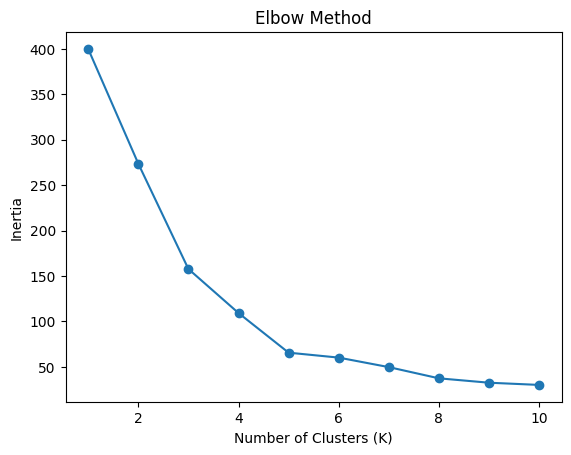

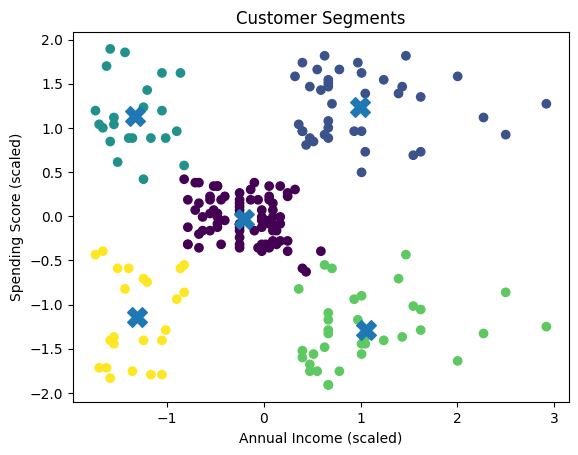

Silhouette Score: 0.5546571631111091


In [4]:
#scenario 1
print("SWASTHIKA M 24BAD121")
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 2. Load dataset
data = pd.read_csv("Mall_Customers.csv")

# 3. Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# 4. Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# 6. Apply K-Means (choose K=5 typically)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 7. Assign cluster labels
data['Cluster'] = labels

# 8. Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# 9. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

SWASTHIKA M 24BAD121


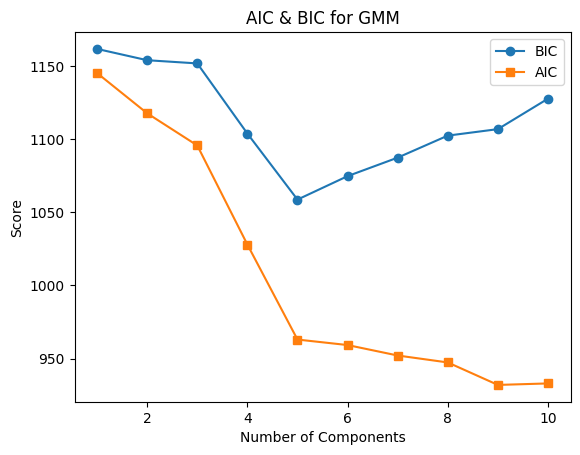

Log Likelihood: -2.262502621973241
Silhouette Score: 0.5536892843811245


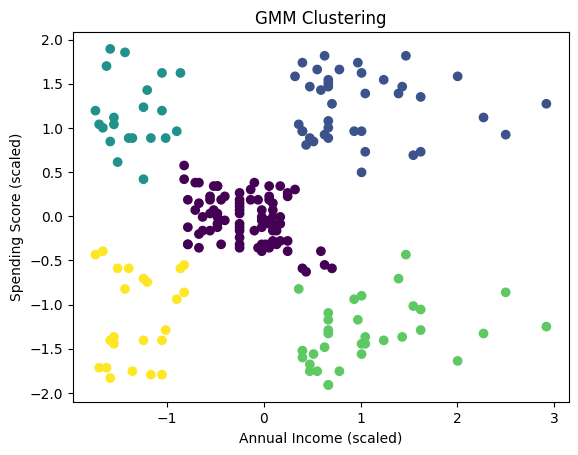

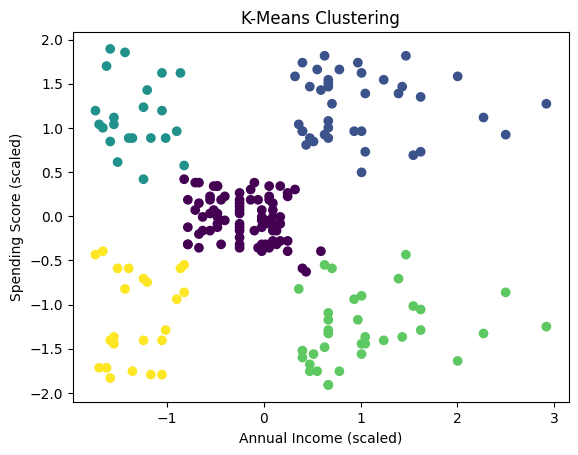

Cluster Probabilities (first 5 data points):
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [3]:
#scenario 2
print("SWASTHIKA M 24BAD121")
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 2. Load dataset
data = pd.read_csv("Mall_Customers.csv")

# 3. Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Find optimal clusters using BIC
bic = []
aic = []
n_components = range(1, 11)

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))
    aic.append(gmm.aic(X_scaled))

# Plot BIC & AIC
plt.plot(n_components, bic, label='BIC', marker='o')
plt.plot(n_components, aic, label='AIC', marker='s')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC & BIC for GMM")
plt.legend()
plt.show()

# 6. Apply GMM (choose n=5 based on graph)
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# 7. Predict cluster probabilities
probabilities = gmm.predict_proba(X_scaled)

# 8. Assign clusters (highest probability)
labels = gmm.predict(X_scaled)
data['GMM_Cluster'] = labels

# 9. Log Likelihood
log_likelihood = gmm.score(X_scaled)
print("Log Likelihood:", log_likelihood)

# 10. Silhouette Score
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

# 11. Visualization of clusters
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# 12. Compare with K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=k_labels)
plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# 13. Print probabilities (first 5 rows)
print("Cluster Probabilities (first 5 data points):")
print(probabilities[:5])